In [4]:
import pandas as pd

In [7]:
url_data = 'https://raw.githubusercontent.com/WeronikaR4/AI/main/data/data.csv'
url_heart = 'https://raw.githubusercontent.com/WeronikaR4/AI/main/data/heart.csv'

In [8]:
df_data = pd.read_csv(url_data)
df_heart = pd.read_csv(url_heart)

In [9]:
print("Dane Breast Cancer:")
print(df_data.head())

print("\n-------------------\n")

print("Dane Heart:")
print(df_heart.head())

Dane Breast Cancer:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  ar

In [10]:
print(f"Zbiór Breast Cancer - próbki (wiersze): {df_data.shape[0]}, cechy (kolumny): {df_data.shape[1]}")
print(f"Zbiór Heart - próbki (wiersze): {df_heart.shape[0]}, cechy (kolumny): {df_heart.shape[1]}")
print("\n" + "-"*40 + "\n")

Zbiór Breast Cancer - próbki (wiersze): 569, cechy (kolumny): 33
Zbiór Heart - próbki (wiersze): 303, cechy (kolumny): 14

----------------------------------------



In [11]:
print(f"Łączna liczba brakujących wartości w zbiorze Breast Cancer: {df_data.isna().sum().sum()}")
print(f"Łączna liczba brakujących wartości w zbiorze Heart: {df_heart.isna().sum().sum()}")

Łączna liczba brakujących wartości w zbiorze Breast Cancer: 569
Łączna liczba brakujących wartości w zbiorze Heart: 0


In [12]:
print("Kolumny w zbiorze Breast Cancer:")
print(df_data.columns.tolist())

print("\n" + "-"*40 + "\n")

print("Kolumny w zbiorze Heart:")
print(df_heart.columns.tolist())

Kolumny w zbiorze Breast Cancer:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

----------------------------------------

Kolumny w zbiorze Heart:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [1]:
liczba_klas = df_data['diagnosis'].value_counts()

print("Podział klas w zbiorze Breast Cancer:")
print(liczba_klas)

NameError: name 'df_data' is not defined

In [2]:
import pandas as pd

url_data = 'https://raw.githubusercontent.com/WeronikaR4/AI/main/data/data.csv'
df_data = pd.read_csv(url_data)

liczba_klas = df_data['diagnosis'].value_counts()

print("Podział klas w zbiorze Breast Cancer:")
print(liczba_klas)

Podział klas w zbiorze Breast Cancer:
diagnosis
B    357
M    212
Name: count, dtype: int64


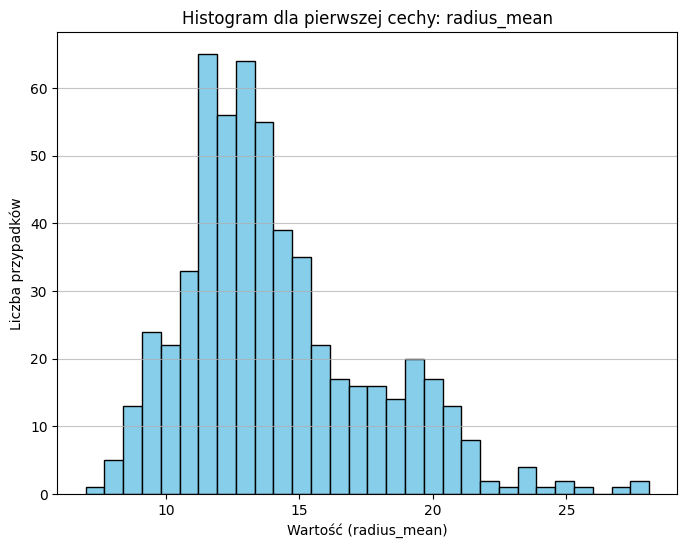

In [3]:
import matplotlib.pyplot as plt

pierwsza_cecha = df_data.columns[2]

plt.figure(figsize=(8, 6))
plt.hist(df_data[pierwsza_cecha], bins=30, color='skyblue', edgecolor='black')

plt.title(f'Histogram dla pierwszej cechy: {pierwsza_cecha}')
plt.xlabel(f'Wartość ({pierwsza_cecha})')
plt.ylabel('Liczba przypadków')
plt.grid(axis='y', alpha=0.75)

plt.show()

C:\Users\weron\AppData\Local\Temp\ipykernel_26412\2624735283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=pierwsza_cecha, data=df_data, palette='Set2')


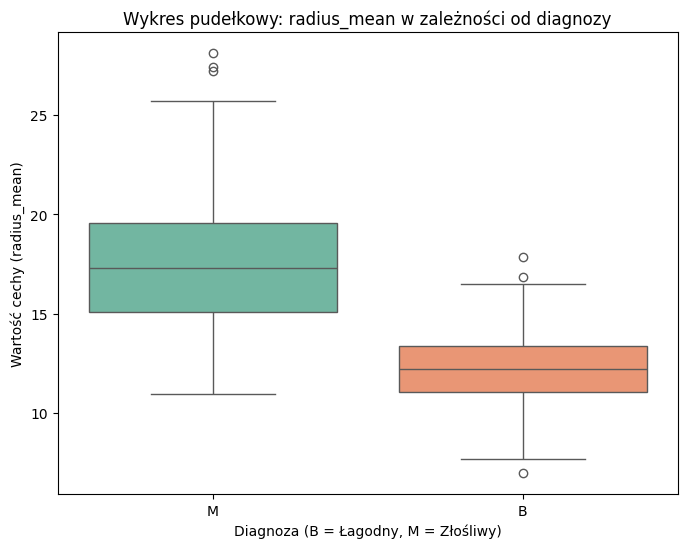

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

pierwsza_cecha = df_data.columns[2]

plt.figure(figsize=(8, 6))

sns.boxplot(x='diagnosis', y=pierwsza_cecha, data=df_data, palette='Set2')

plt.title(f'Wykres pudełkowy: {pierwsza_cecha} w zależności od diagnozy')
plt.xlabel('Diagnoza (B = Łagodny, M = Złośliwy)')
plt.ylabel(f'Wartość cechy ({pierwsza_cecha})')

plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

In [6]:
kolumny_do_usuniecia = ['diagnosis', 'id']
if 'Unnamed: 32' in df_data.columns:
    kolumny_do_usuniecia.append('Unnamed: 32')

X = df_data.drop(columns=kolumny_do_usuniecia)
y = df_data['diagnosis']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train) 
y_pred_dummy = dummy_clf.predict(X_test)

In [11]:
baseline_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Accuracy modelu bazowego (Baseline): {baseline_accuracy:.4f}")

Accuracy modelu bazowego (Baseline): 0.6316
